# Klasifikasi Survival Penumpang Titanic Menggunakan ResNet50 sebagai Ekstraktor Fitur Berbasis TensorFlow dengan Optimisasi Gauss–Newton pada Head Klasifikasi


2026-04-14 14:21:05.439722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776176465.735973      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776176465.833634      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776176466.496885      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776176466.496931      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776176466.496935      16 computation_placer.cc:177] computation placer alr

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Using ResNet50 with ImageNet weights.
ResNet50 feature shape: (891, 2048)
CV mean -> Acc: 0.6745 | Prec: 0.5794 | Rec: 0.5436 | F1: 0.5594
OOF     -> Acc: 0.6745 | Prec: 0.5813 | Rec: 0.5439 | F1: 0.5619


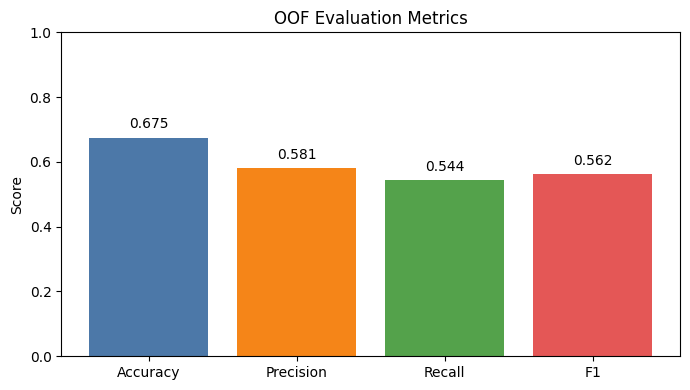

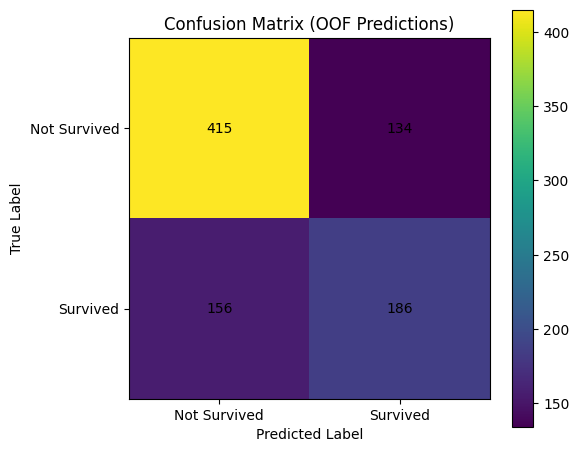

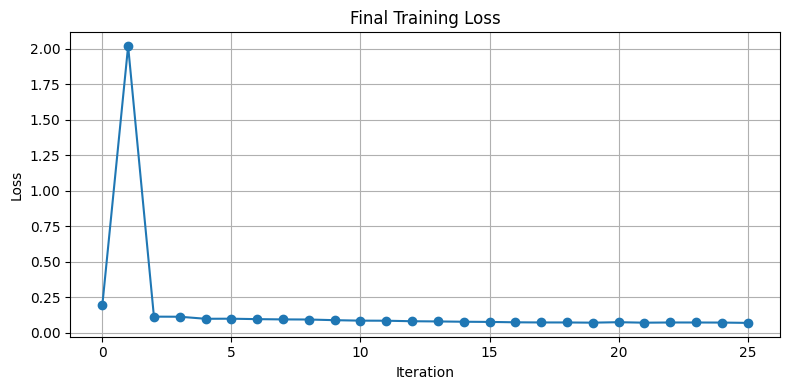


Submission preview:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
submission.csv saved.
Saved plots: oof_metrics.png, confusion_matrix.png, finalLoss.png


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load data
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

full = pd.concat([train.drop(columns=["Survived"]), test], axis=0).reset_index(drop=True)

# Preprocessing + feature engineering
full["Title"] = full["Name"].str.extract(r",\s*([^\.]+)\.")
rare = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
full["Title"] = full["Title"].replace(rare, "Rare")
full["Title"] = full["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

full["FamilySize"] = full["SibSp"] + full["Parch"] + 1
full["IsAlone"] = (full["FamilySize"] == 1).astype(int)

full["Deck"] = full["Cabin"].fillna("U").str[0]

ticketCounts = full["Ticket"].value_counts()
full["TicketGroupSize"] = full["Ticket"].map(ticketCounts)

full["Fare"] = full["Fare"].fillna(full.groupby("Pclass")["Fare"].transform("median"))
full["FarePerPerson"] = full["Fare"] / full["FamilySize"]

full["Embarked"] = full["Embarked"].fillna(full["Embarked"].mode()[0])

full["Age"] = full["Age"].fillna(
    full.groupby(["Sex", "Pclass", "Title"])["Age"].transform("median")
)
full["Age"] = full["Age"].fillna(full["Age"].median())

full = full.drop(columns=["Name", "Ticket", "Cabin"])

catCols = full.select_dtypes(include="object").columns
for col in catCols:
    full[col] = full[col].fillna("Missing")
    le = LabelEncoder()
    full[col] = le.fit_transform(full[col])

X = full.iloc[:len(train)].copy()
xTest = full.iloc[len(train):].copy()
y = train["Survived"].astype(int).values

# Normalize tabular data
tabScaler = StandardScaler()
X = tabScaler.fit_transform(X).astype(np.float32)
xTest = tabScaler.transform(xTest).astype(np.float32)

# Convert tabular -> pseudo-image for ResNet50
IMG_H, IMG_W, IMG_C = 32, 32, 3
TOTAL_PIXELS = IMG_H * IMG_W * IMG_C

def tabularToPseudoImage(arr):
    arr = np.asarray(arr, dtype=np.float32)
    nSamples, nFeatures = arr.shape

    repeatCount = int(np.ceil(TOTAL_PIXELS / nFeatures))
    tiled = np.tile(arr, (1, repeatCount))[:, :TOTAL_PIXELS]
    imgs = tiled.reshape(nSamples, IMG_H, IMG_W, IMG_C)

    mins = imgs.min(axis=(1, 2, 3), keepdims=True)
    maxs = imgs.max(axis=(1, 2, 3), keepdims=True)
    imgs = (imgs - mins) / (maxs - mins + 1e-8)
    imgs = imgs * 255.0

    imgs = preprocess_input(imgs)
    return imgs.astype(np.float32)

xImg = tabularToPseudoImage(X)
xTestImg = tabularToPseudoImage(xTest)

# ResNet50 feature extractor
try:
    resnet = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_H, IMG_W, IMG_C),
        pooling="avg"
    )
    print("Using ResNet50 with ImageNet weights.")
except Exception as e:
    print("ImageNet weights unavailable, using random weights instead.")
    print("Reason:", e)
    resnet = ResNet50(
        include_top=False,
        weights=None,
        input_shape=(IMG_H, IMG_W, IMG_C),
        pooling="avg"
    )

resnet.trainable = False

def extractResnetFeatures(model, images, batchSize=64):
    ds = tf.data.Dataset.from_tensor_slices(images).batch(batchSize)
    feats = model.predict(ds, verbose=0)
    return feats.astype(np.float64)

xFeat = extractResnetFeatures(resnet, xImg)
xTestFeat = extractResnetFeatures(resnet, xTestImg)

print("ResNet50 feature shape:", xFeat.shape)

# Pure Gauss-Newton nonlinear head
class PureGaussNewtonMLP:
    def __init__(self, inputDim, hiddenDim=8, seed=42):
        rng = np.random.default_rng(seed)
        self.inputDim = inputDim
        self.hiddenDim = hiddenDim

        self.W1 = rng.normal(0, 0.05, size=(inputDim, hiddenDim))
        self.b1 = np.zeros(hiddenDim, dtype=np.float64)
        self.W2 = rng.normal(0, 0.05, size=(hiddenDim, 1))
        self.b2 = np.zeros(1, dtype=np.float64)

        self.loss_history = []

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = np.tanh(z1)
        yHat = a1 @ self.W2 + self.b2
        return yHat.ravel(), a1

    def residuals(self, X, y):
        yHat, _ = self.forward(X)
        return yHat - y

    def get_theta(self):
        return np.concatenate([
            self.W1.ravel(),
            self.b1.ravel(),
            self.W2.ravel(),
            self.b2.ravel()
        ])

    def set_theta(self, theta):
        idx = 0

        w1Size = self.inputDim * self.hiddenDim
        self.W1 = theta[idx:idx + w1Size].reshape(self.inputDim, self.hiddenDim)
        idx += w1Size

        b1Size = self.hiddenDim
        self.b1 = theta[idx:idx + b1Size]
        idx += b1Size

        w2Size = self.hiddenDim
        self.W2 = theta[idx:idx + w2Size].reshape(self.hiddenDim, 1)
        idx += w2Size

        self.b2 = theta[idx:idx + 1]

    def jacobian(self, X):
        n, _ = X.shape
        _, a1 = self.forward(X)

        dyDz1 = (1.0 - a1 ** 2) * self.W2.ravel()

        totalParams = (
            self.inputDim * self.hiddenDim +
            self.hiddenDim +
            self.hiddenDim +
            1
        )

        J = np.zeros((n, totalParams), dtype=np.float64)

        for i in range(n):
            xI = X[i]
            a1I = a1[i]
            dyDz1I = dyDz1[i]

            dW1 = np.outer(xI, dyDz1I).ravel()
            db1 = dyDz1I
            dW2 = a1I
            db2 = np.array([1.0], dtype=np.float64)

            J[i] = np.concatenate([dW1, db1, dW2, db2])

        return J

    def fit(self, X, y, maxIter=25, damping=1e-2, tol=1e-7, verbose=False):
        y = y.astype(np.float64)
        self.loss_history = []

        for it in range(maxIter):
            r = self.residuals(X, y)
            lossOld = 0.5 * np.mean(r ** 2)
            self.loss_history.append(lossOld)

            J = self.jacobian(X)

            JTJ = J.T @ J
            JTr = J.T @ r

            A = JTJ + damping * np.eye(JTJ.shape[0], dtype=np.float64)

            try:
                delta = np.linalg.solve(A, JTr)
            except np.linalg.LinAlgError:
                delta = np.linalg.pinv(A) @ JTr

            thetaOld = self.get_theta()
            thetaNew = thetaOld - delta
            self.set_theta(thetaNew)

            r_new = self.residuals(X, y)
            lossNew = 0.5 * np.mean(r_new ** 2)

            if verbose:
                print(
                    f"iter={it+1:02d} "
                    f"loss={lossOld:.8f} "
                    f"new_loss={lossNew:.8f} "
                    f"step_norm={np.linalg.norm(delta):.8f}"
                )

            if np.linalg.norm(delta) < tol:
                if verbose:
                    print(f"Converged at iter {it+1}")
                break

        finalR = self.residuals(X, y)
        finalLoss = 0.5 * np.mean(finalR ** 2)
        self.loss_history.append(finalLoss)

    def predict_raw(self, X):
        yHat, _ = self.forward(X)
        return yHat

    def predict(self, X, threshold=0.5):
        return (self.predict_raw(X) >= threshold).astype(int)

# Per-fold pipeline
def runFold(xTrFeat, yTr, xVaFeat, yVa, xTeFeat, seed=42):
    feat_scaler = StandardScaler()
    xTrFeat = feat_scaler.fit_transform(xTrFeat)
    xVaFeat = feat_scaler.transform(xVaFeat)
    xTeFeat = feat_scaler.transform(xTeFeat)

    pca_dim = min(32, xTrFeat.shape[0], xTrFeat.shape[1])
    pca = PCA(n_components=pca_dim, random_state=seed)
    xTrRed = pca.fit_transform(xTrFeat)
    xVaRed = pca.transform(xVaFeat)
    xTeRed = pca.transform(xTeFeat)

    pca_scaler = StandardScaler()
    xTrRed = pca_scaler.fit_transform(xTrRed)
    xVaRed = pca_scaler.transform(xVaRed)
    xTeRed = pca_scaler.transform(xTeRed)

    model = PureGaussNewtonMLP(
        inputDim=xTrRed.shape[1],
        hiddenDim=8,
        seed=seed
    )

    model.fit(
        xTrRed,
        yTr,
        maxIter=25,
        damping=1e-2,
        tol=1e-7,
        verbose=False
    )

    predVa = model.predict(xVaRed)
    predTe = model.predict(xTeRed)

    metrics = {
        "accuracy": accuracy_score(yVa, predVa),
        "precision": precision_score(yVa, predVa, zero_division=0),
        "recall": recall_score(yVa, predVa, zero_division=0),
        "f1": f1_score(yVa, predVa, zero_division=0)
    }

    return metrics, predVa, predTe

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

accScores = []
precScores = []
recScores = []
f1Scores = []

oofPred = np.zeros(len(y), dtype=int)


for fold, (trIdx, vaIdx) in enumerate(cv.split(xFeat, y), 1):
    xTrFeat, xVaFeat = xFeat[trIdx], xFeat[vaIdx]
    yTr, yVa = y[trIdx], y[vaIdx]

    metrics, predVa, _ = runFold(
        xTrFeat, yTr,
        xVaFeat, yVa,
        xTestFeat,
        seed=SEED + fold
    )

    oofPred[vaIdx] = predVa

    accScores.append(metrics["accuracy"])
    precScores.append(metrics["precision"])
    recScores.append(metrics["recall"])
    f1Scores.append(metrics["f1"])

meanAcc = np.mean(accScores)
meanPrec = np.mean(precScores)
meanRec = np.mean(recScores)
meanF1 = np.mean(f1Scores)

oofAcc = accuracy_score(y, oofPred)
oofPrec = precision_score(y, oofPred, zero_division=0)
oofRec = recall_score(y, oofPred, zero_division=0)
oofF1 = f1_score(y, oofPred, zero_division=0)

print("CV mean -> Acc: {:.4f} | Prec: {:.4f} | Rec: {:.4f} | F1: {:.4f}".format(meanAcc, meanPrec, meanRec, meanF1))
print("OOF     -> Acc: {:.4f} | Prec: {:.4f} | Rec: {:.4f} | F1: {:.4f}".format(oofAcc, oofPrec, oofRec, oofF1))

metricsNames = ["Accuracy", "Precision", "Recall", "F1"]
metricsValues = [oofAcc, oofPrec, oofRec, oofF1]

plt.figure(figsize=(7, 4))
bars = plt.bar(metricsNames, metricsValues, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
plt.ylim(0, 1)
plt.title("OOF Evaluation Metrics")
plt.ylabel("Score")
for bar, val in zip(bars, metricsValues):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("oof_metrics.png", dpi=200)
plt.show()

# Plot: Confusion Matrix from OOF predictions
cm = confusion_matrix(y, oofPred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (OOF Predictions)")
plt.colorbar()

tickMarks = np.arange(2)
plt.xticks(tickMarks, ["Not Survived", "Survived"])
plt.yticks(tickMarks, ["Not Survived", "Survived"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

# Final training on full training set
fullFeatScaler = StandardScaler()
xFeatFull = fullFeatScaler.fit_transform(xFeat)
xTestFeatFull = fullFeatScaler.transform(xTestFeat)

fullPcaDim = min(32, xFeatFull.shape[0], xFeatFull.shape[1])
fullPca = PCA(n_components=fullPcaDim, random_state=SEED)
xRed = fullPca.fit_transform(xFeatFull)
xTestRed = fullPca.transform(xTestFeatFull)

fullPcaScaler = StandardScaler()
xRed = fullPcaScaler.fit_transform(xRed)
xTestRed = fullPcaScaler.transform(xTestRed)

finalModel = PureGaussNewtonMLP(
    inputDim=xRed.shape[1],
    hiddenDim=8,
    seed=SEED
)

finalModel.fit(
    xRed,
    y,
    maxIter=25,
    damping=1e-2,
    tol=1e-7,
    verbose=False
)

plt.figure(figsize=(8, 4))
plt.plot(finalModel.loss_history, marker='o')
plt.title("Final Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("finalLoss.png", dpi=200)
plt.show()

predTest = finalModel.predict(xTestRed).astype(int)

# Save submission
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predTest
})

submission.to_csv("submission.csv", index=False)

print("\nSubmission preview:")
print(submission.head())
print("submission.csv saved.")
print("Saved plots: oof_metrics.png, confusion_matrix.png, finalLoss.png")